In [1]:
import pandas as pd

df = pd.read_csv('../Datasets/HousePricePrediction.csv')
print(df.head())

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [2]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB
None
                Id   MSSubClass        LotArea  OverallCond    YearBuilt  \
count  2919.000000  2919.000000    2919.000000  2919.000000  2919.000000   
mean   1459.000000    57.13

In [ ]:
df = df.dropna(subset=["SalePrice"])

In [4]:
print(df.shape)

(1460, 13)


In [ ]:
feature = "TotalBsmtSF"

X = df[[feature]]
y = df["SalePrice"]

In [6]:
data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[[feature]]
y = data["SalePrice"]

In [ ]:
import numpy as np

# X = X.values
# y = y.values

print(X.shape)
print(y.shape)

(1460, 1)
(1460,)


**ACTUAL LINEAR REGRESSION**

In [15]:
# number of features
n_features = X.shape[1]

# initialize
w = np.zeros(n_features)
b = 0

print(w)
print(b)

[0.]
0


In [16]:
def predict(X, w, b):
    return np.dot(X, w) + b

In [17]:
y_pred = predict(X, w, b)

print(y_pred[:5])

[0. 0. 0. 0. 0.]


In [18]:
def compute_cost(y, y_pred):
    n = len(y)
    cost = (1/n) * np.sum((y - y_pred) ** 2)
    return cost

In [19]:
cost = compute_cost(y, y_pred)
print(cost)

39039267707.765755


In [20]:
def gradient_descent(X, y, w, b, learning_rate):
    n = len(y)
    
    y_pred = predict(X, w, b)
    
    dw = (1/n) * np.dot(X.T, (y_pred - y))
    db = (1/n) * np.sum(y_pred - y)
    
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    return w, b

In [21]:
w, b = gradient_descent(X, y, w, b, learning_rate=0.00000001)

print(w, b)

[2.12681171] 0.0018092119589041096


In [22]:
epochs = 1000
learning_rate = 0.00000001

costs = []

for i in range(epochs):
    y_pred = predict(X, w, b)
    
    cost = compute_cost(y, y_pred)
    costs.append(cost)
    
    w, b = gradient_descent(X, y, w, b, learning_rate)
    
    if i % 100 == 0:
        print(f"Iteration {i}, Cost: {cost}")

Iteration 0, Cost: 38140529217.31384
Iteration 100, Cost: 6925964260.099313
Iteration 200, Cost: 4694668046.336257
Iteration 300, Cost: 4535169188.519228
Iteration 400, Cost: 4523767645.815284
Iteration 500, Cost: 4522952473.77199
Iteration 600, Cost: 4522894042.279226
Iteration 700, Cost: 4522889704.515057
Iteration 800, Cost: 4522889233.50747
Iteration 900, Cost: 4522889038.90547


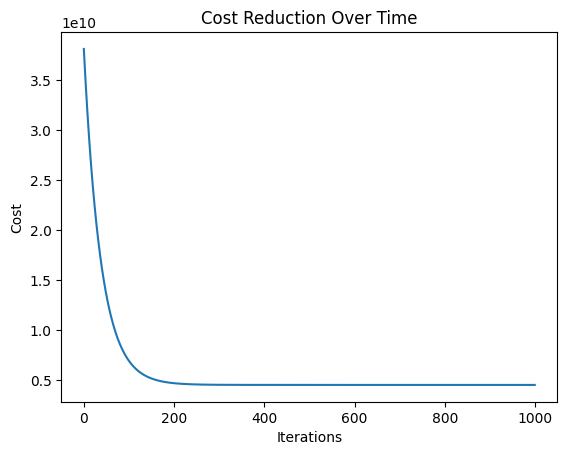

In [23]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction Over Time")
plt.show()

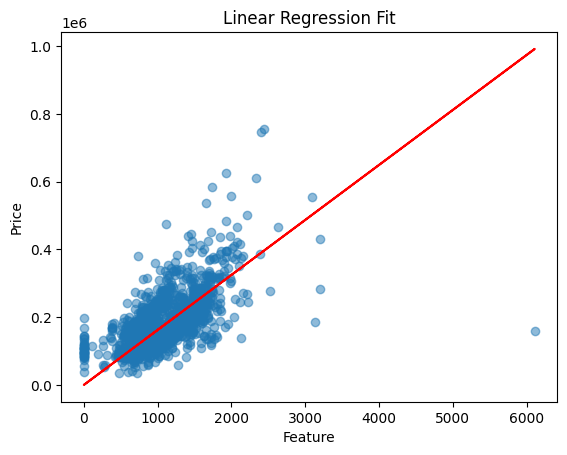

In [24]:
plt.scatter(X, y, alpha=0.5)
plt.plot(X, predict(X, w, b), color='red')
plt.xlabel("Feature")
plt.ylabel("Price")
plt.title("Linear Regression Fit")
plt.show()

In [25]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix["SalePrice"].sort_values(ascending=False))

SalePrice       1.000000
TotalBsmtSF     0.613581
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
BsmtFinSF2     -0.011378
Id             -0.021917
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64


In [26]:
features = ["TotalBsmtSF", "YearBuilt", "YearRemodAdd"]

In [27]:
X = df[features]
y = df["SalePrice"]

data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[features]
y = data["SalePrice"]

In [28]:
X = X.values
y = y.values

In [29]:
print(X.shape)

(1460, 3)


In [30]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X = (X - mean) / std

In [36]:
n_features = X.shape[1]

w = np.zeros(n_features)
b = 0

In [37]:
epochs = 1000
learning_rate = 0.01

costs = []

for i in range(epochs):
    y_pred = predict(X, w, b)
    
    cost = compute_cost(y, y_pred)
    costs.append(cost)
    
    w, b = gradient_descent(X, y, w, b, learning_rate)
    
    if i % 100 == 0:
        print(f"Iteration {i}, Cost: {cost}")

Iteration 0, Cost: 39039267707.765755
Iteration 100, Cost: 7584731457.426878
Iteration 200, Cost: 3667299770.067433
Iteration 300, Cost: 3143385623.336672
Iteration 400, Cost: 3071355790.366892
Iteration 500, Cost: 3061010163.5868545
Iteration 600, Cost: 3059354994.3231406
Iteration 700, Cost: 3059022010.4063053
Iteration 800, Cost: 3058929414.5338774
Iteration 900, Cost: 3058895809.051334


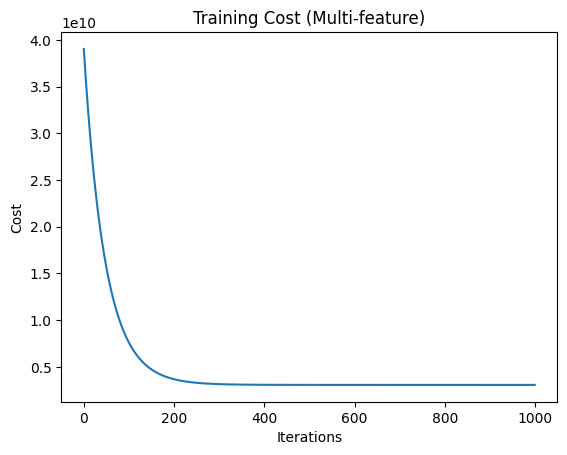

In [38]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Cost (Multi-feature)")
plt.show()

In [48]:
X = df[features]
y = df["SalePrice"]

data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[features]
y = data["SalePrice"]

In [49]:
X = X.values
y = y.values

In [50]:
print(X.shape)

(1460, 3)


In [51]:
# number of samples
n = X.shape[0]

# shuffle indices
indices = np.random.permutation(n)

# split point
split = int(0.8 * n)

train_idx = indices[:split]
test_idx = indices[split:]

# create splits
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [52]:
print(X_train.shape, X_test.shape)

(1168, 3) (292, 3)


In [53]:
# Step 1: already split

# Step 2: compute from training only
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Step 3: scale both
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [54]:
# reinitialize
w = np.zeros(X_train.shape[1])
b = 0

costs = []

epochs = 1000
learning_rate = 0.01

for i in range(epochs):
    y_pred = predict(X_train, w, b)
    
    cost = compute_cost(y_train, y_pred)
    costs.append(cost)
    
    w, b = gradient_descent(X_train, y_train, w, b, learning_rate)

In [55]:
print(costs[-1])

3168306279.6616416


In [56]:
y_test_pred = predict(X_test, w, b)

test_cost = compute_cost(y_test, y_test_pred)

print("Test Cost:", test_cost)

Test Cost: 2628302853.0591083


In [57]:
def r2_score(y, y_pred):
    ss_total = np.sum((y - np.mean(y))**2)
    ss_residual = np.sum((y - y_pred)**2)
    return 1 - (ss_residual / ss_total)

In [58]:
r2 = r2_score(y_test, y_test_pred)
print("R2 Score:", r2)

R2 Score: 0.5659609530292624
